In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv(r'C:\Users\renee\Projects\BuyHerePayLater_Credit_Prediction\Data\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')


#Viewing all Columns
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  str    
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  str    
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  str    
 13  transaction_date      10345 non-null  str    
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score            10345 no

In [14]:
#Filtering Columns 
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment'],
      dtype='str')

In [15]:
#Keeping only columns needed for research
df = df[['age', 'monthly_income', 'credit_score',
       'repayment_delay_days', 'missed_payments',
        'location', 
       'debt_to_income_ratio', 'risk_score', 'customer_segment']]

In [16]:
df.head(10)

print(df.shape)

(10345, 9)


In [17]:
df.dtypes

age                       int64
monthly_income          float64
credit_score              int64
repayment_delay_days      int64
missed_payments           int64
location                    str
debt_to_income_ratio    float64
risk_score              float64
customer_segment            str
dtype: object

In [18]:
# Change monthly_income to (int) from float64
df['monthly_income'] = df['monthly_income'].astype(int)



In [19]:
#checking for missing values
df.isna()

df.isna().sum()

age                     0
monthly_income          0
credit_score            0
repayment_delay_days    0
missed_payments         0
location                0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

In [20]:
#checking for duplicates
df.duplicated(keep=False).sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
10340    False
10341    False
10342    False
10343    False
10344    False
Length: 10345, dtype: bool>

In [21]:
df['location'].value_counts()

location
Germany      1760
Canada       1740
USA          1736
India        1723
Australia    1722
UK           1664
Name: count, dtype: int64

In [22]:
#filtering for USA
us_bnpl_df = df[df['location'] == 'USA'].copy()

In [23]:
#viewing monthly income of users
df['monthly_income'].describe()

count     10345.000000
mean      35052.907105
std       27084.503349
min        5000.000000
25%       12207.000000
50%       23800.000000
75%       55276.000000
max      145767.000000
Name: monthly_income, dtype: float64

In [24]:
#Create a true montly income column by dividing the annual values by 12
df['true_monthly_income'] = df['monthly_income'] / 12

#Checking new  stats
df['true_monthly_income'].describe()

count    10345.000000
mean      2921.075592
std       2257.041946
min        416.666667
25%       1017.250000
50%       1983.333333
75%       4606.333333
max      12147.250000
Name: true_monthly_income, dtype: float64

In [25]:
df['credit_score'].value_counts()

credit_score
300    1373
341      54
308      53
320      51
337      50
       ... 
809       1
846       1
795       1
766       1
808       1
Name: count, Length: 534, dtype: int64

In [26]:
df['age'].value_counts()

age
26    274
51    268
53    266
35    266
20    265
55    262
21    261
45    260
28    260
24    259
40    259
57    257
50    255
43    252
54    251
59    251
31    251
39    250
46    250
33    248
49    248
52    247
27    247
19    244
32    244
44    243
42    243
22    242
48    239
30    238
36    236
37    234
29    233
47    231
38    231
25    231
56    227
58    227
34    225
41    225
23    223
18    222
Name: count, dtype: int64

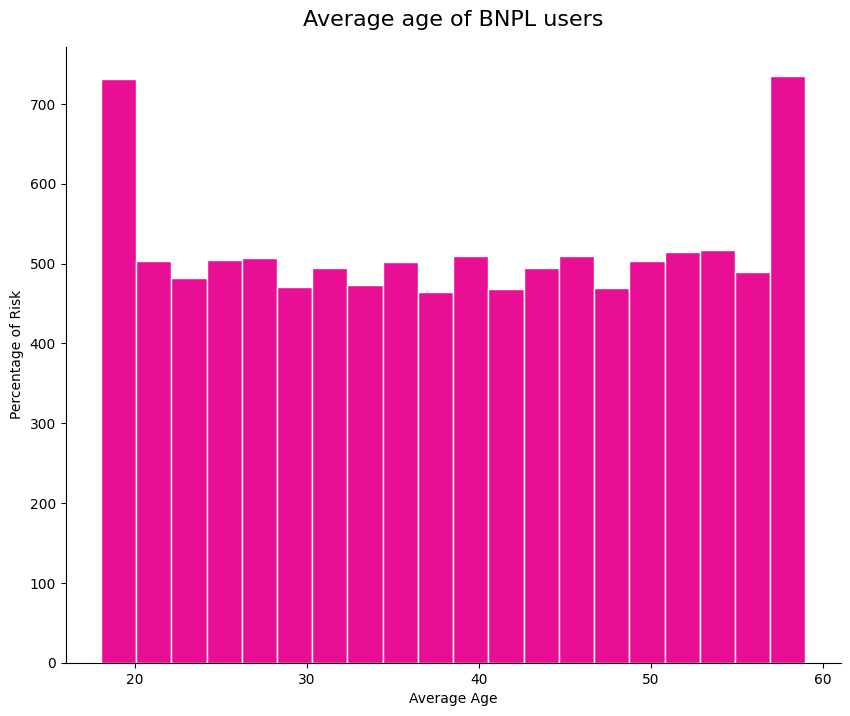

In [27]:
#Which age group are at the hightest risk 
#Visualation (Histogram)


plt.figure(figsize=(10,8))
plt.hist(
    df["age"],
    bins=20,
    color="#e90f95",
    edgecolor = "white"
)


plt.xlabel("Average Age")
plt.ylabel("Percentage of Risk")
plt.title("Average age of BNPL users", fontsize=16, pad=15)

ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()
    

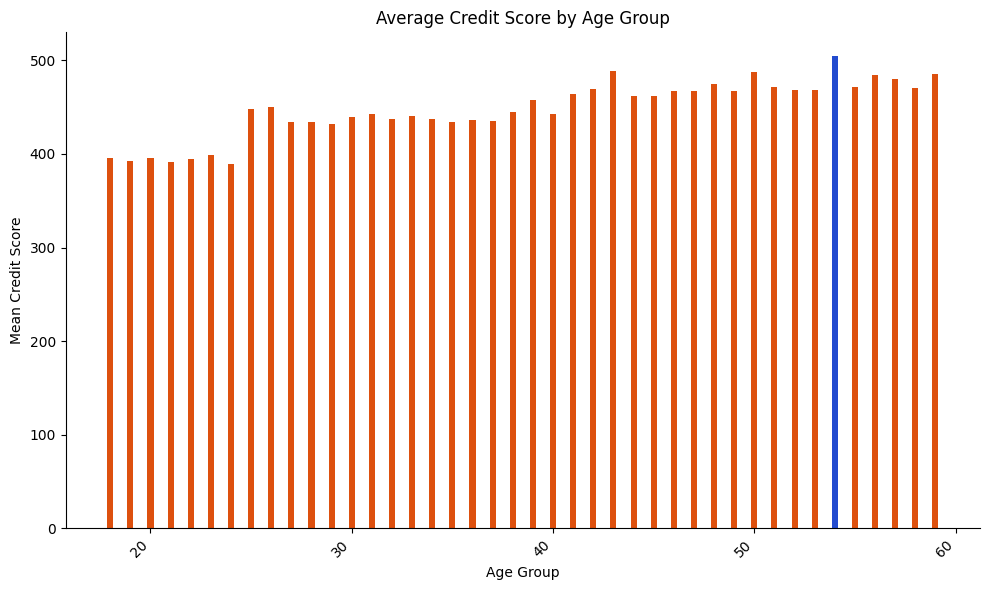

In [28]:
#Grouping by age and calculating the mean credit score
avg_credit_by_age = df.groupby('age')['credit_score'].mean().reset_index()

#Plot and default color
plt.figure(figsize=(10,6))
colors = ["#dd500e"]*len(avg_credit_by_age)

#Bar Color
max_index = avg_credit_by_age['credit_score'].idxmax()
highlight_position = avg_credit_by_age.index.get_loc(max_index)
colors[max_index] = "#123eccee"

plt.bar(avg_credit_by_age['age'], avg_credit_by_age['credit_score'], color = colors, width =0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Age Group")
plt.ylabel("Mean Credit Score")
plt.title("Average Credit Score by Age Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

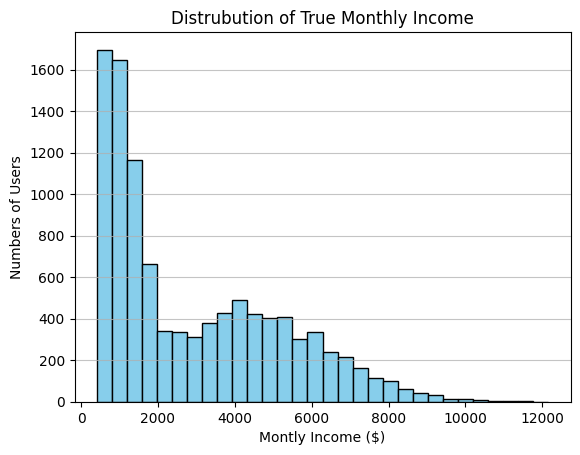

In [29]:
#Plotting a histogram of the true monthly income
plt.hist(df['true_monthly_income'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distrubution of True Monthly Income')
plt.xlabel('Montly Income ($)')
plt.ylabel('Numbers of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()